<a href="https://colab.research.google.com/github/DogwonLee/Gold_Price/blob/main/GoldPrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv("/content/Gold_vs_Economic_Factors_2015_2026.csv")
df

,Date,Gold_Price_XAU_USD,US_Dollar_Index_DXY,Crude_Oil_Price,Inflation_Rate_Pct
0,2015-01-01,1205.47,95.17,47.85,7.92
1,2015-01-02,1204.58,95.61,48.71,6.17
2,2015-01-03,1211.56,95.62,53.73,4.80
3,2015-01-04,1227.29,95.93,55.39,6.95
4,2015-01-05,1225.45,96.75,53.76,5.99
...,...,...,...,...,...
4132,2026-04-25,3960.04,38.80,454.37,3.32
4133,2026-04-26,3973.25,38.06,452.81,2.71
4134,2026-04-27,3972.65,38.59,451.23,2.47
4135,2026-04-28,3969.26,38.32,447.60,4.06


| 변수 이름 | 설명 |
| --- | --- |
| Date | 날짜 |
| Gold_Price_XAU_USD | 달러 기준 금 시세 |
| US_Dollar_Index_DXY | 달러가 다른 주요 통화들 대비 얼마나 강한지 나타내는 지표 |
| Crude_Oil_Price | 원유 가격 / 국제 유가 |
| Inflation_Rate_Pct | 물가 상승률 |

##결측치

In [ ]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Date                   0
Gold_Price_XAU_USD     0
US_Dollar_Index_DXY    0
Crude_Oil_Price        0
Inflation_Rate_Pct     0
dtype: int64




> 결측치 없음



##이상치


In [ ]:
print('\nDescriptive statistics of the DataFrame:')
display(df.describe())


Descriptive statistics of the DataFrame:


,Gold_Price_XAU_USD,US_Dollar_Index_DXY,Crude_Oil_Price,Inflation_Rate_Pct
count,4137.000000,4137.000000,4137.000000,4137.000000
mean,2825.359197,55.311615,274.739901,5.065886
std,927.408308,17.148820,88.498329,2.011200
min,1106.380000,27.050000,47.850000,1.500000
25%,2034.880000,39.280000,227.140000,3.370000
50%,3047.790000,53.110000,282.700000,5.090000
75%,3625.970000,72.520000,320.750000,6.760000
max,4176.600000,97.090000,463.810000,8.500000


##EDA

###전반적인 금값 변화

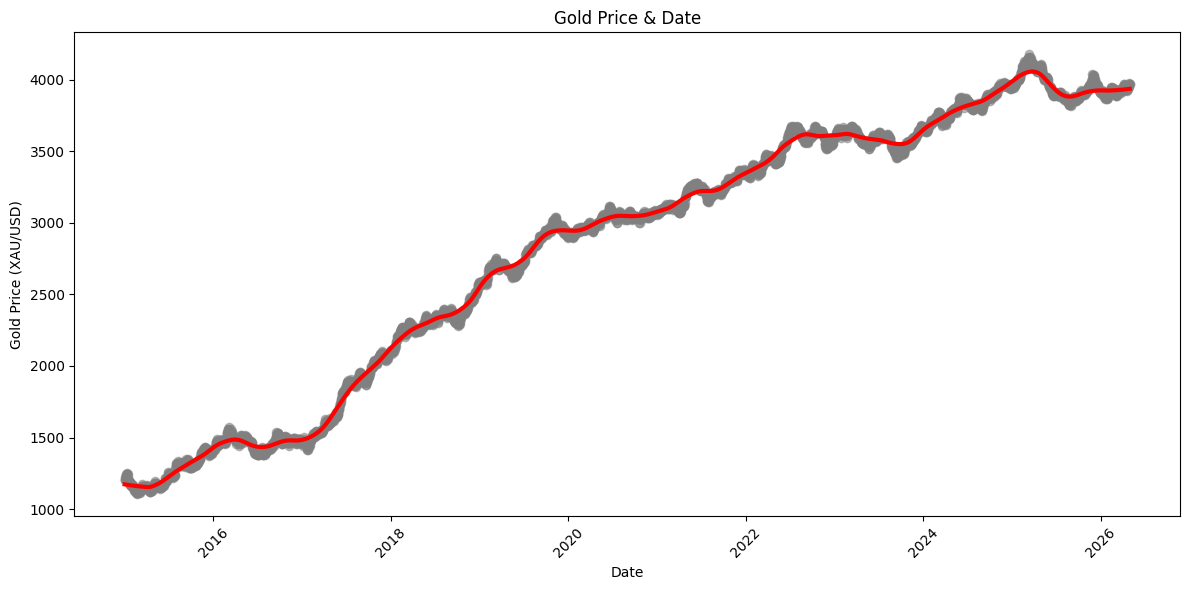

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# CSV 불러오기
df = pd.read_csv("Gold_vs_Economic_Factors_2015_2026.csv")

# Date를 datetime 형식으로 변환
df["Date"] = pd.to_datetime(df["Date"])

# 변수 지정
x = df["Date"]
y = df["Gold_Price_XAU_USD"]

# LOWESS 계산용 숫자 변환
x_num = x.map(pd.Timestamp.toordinal)

# LOWESS 계산
lowess = sm.nonparametric.lowess(
    endog=y,
    exog=x_num,
    frac=0.05
)

# 그래프 생성
plt.figure(figsize=(12, 6))

# 산점도 (검은색)
plt.scatter(x, y, color="grey", alpha=0.5)

# LOWESS 선 (빨간색)
plt.plot(
    pd.to_datetime([pd.Timestamp.fromordinal(int(i)) for i in lowess[:, 0]]),
    lowess[:, 1],
    color="red",
    linewidth=3
)

# 제목 및 축
plt.title("Gold Price & Date")
plt.xlabel("Date")
plt.ylabel("Gold Price (XAU/USD)")

# x축 날짜 자동 정리
plt.xticks(rotation=45)

# 레이아웃 정리
plt.tight_layout()

# 출력
plt.show()

###독립변수들 사이의 관계

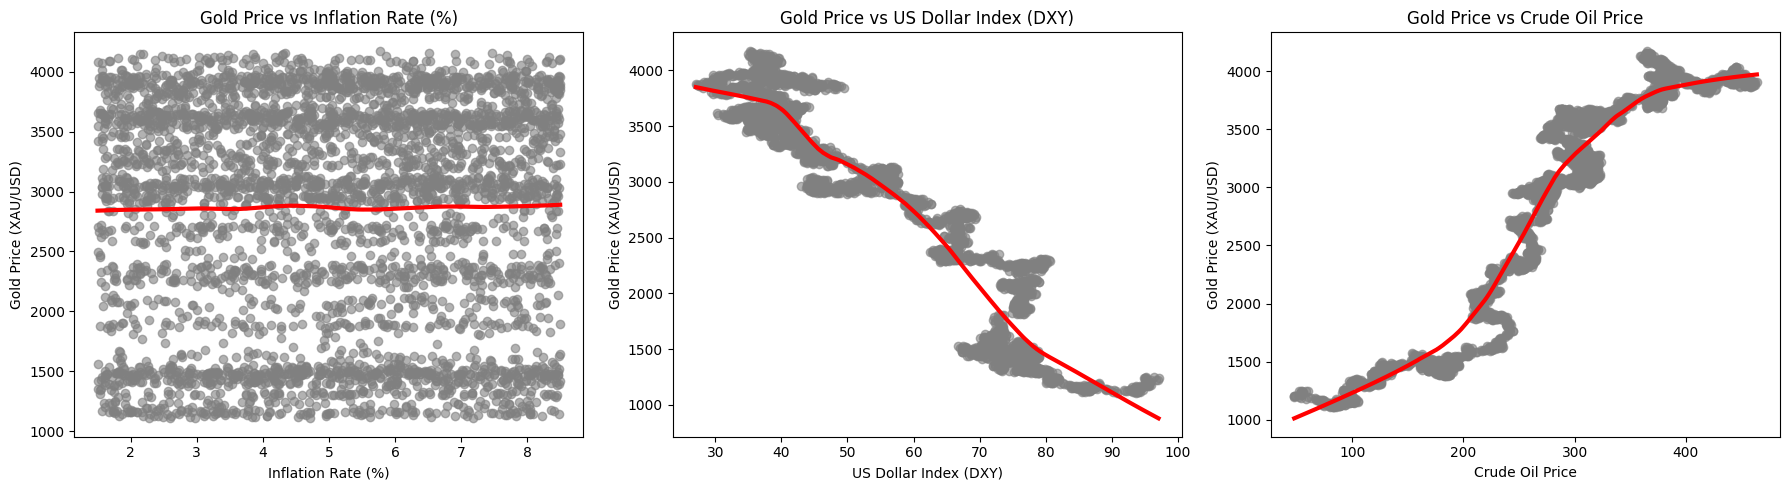

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# CSV 불러오기
df = pd.read_csv("Gold_vs_Economic_Factors_2015_2026.csv")

# 그래프 설정
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 분석할 변수들
variables = [
    ("Inflation_Rate_Pct", "Inflation Rate (%)"),
    ("US_Dollar_Index_DXY", "US Dollar Index (DXY)"),
    ("Crude_Oil_Price", "Crude Oil Price")
]

# 반복문으로 그래프 생성
for ax, (col, label) in zip(axes, variables):

    x = df[col]
    y = df["Gold_Price_XAU_USD"]

    # LOWESS 계산
    lowess = sm.nonparametric.lowess(
        endog=y,
        exog=x,
        frac=0.4
    )

    # 산점도 (검은색)
    ax.scatter(x, y, color="grey", alpha=0.6)

    # LOWESS 선 (빨간색)
    ax.plot(lowess[:, 0], lowess[:, 1],
            color="red", linewidth=3)

    # 제목 및 축
    ax.set_title(f"Gold Price vs {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Gold Price (XAU/USD)")

# 레이아웃 정리
plt.tight_layout()

# 출력
plt.show()

## 계절성을 띠는가?

In [ ]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and day of week
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.dayofweek # Monday=0, Sunday=6

# Calculate average gold price by month
monthly_avg_gold = df.groupby('Month')['Gold_Price_XAU_USD'].mean().reset_index()

# Calculate average gold price by day of week
dayofweek_avg_gold = df.groupby('Day_of_Week')['Gold_Price_XAU_USD'].mean().reset_index()

# Map day of week numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dayofweek_avg_gold['Day_of_Week_Name'] = dayofweek_avg_gold['Day_of_Week'].map(lambda x: day_names[x])

print("Average Gold Price by Month:")
display(monthly_avg_gold)

print("\nAverage Gold Price by Day of Week:")
display(dayofweek_avg_gold)

Average Gold Price by Month:


,Month,Gold_Price_XAU_USD
0,1,2779.157419
1,2,2819.101416
2,3,2842.525054
3,4,2836.435181
4,5,2756.722786
5,6,2786.383303
6,7,2806.420528
7,8,2813.292287
8,9,2821.506758
9,10,2850.620997



Average Gold Price by Day of Week:


,Day_of_Week,Gold_Price_XAU_USD,Day_of_Week_Name
0,0,2825.759695,Monday
1,1,2826.272589,Tuesday
2,2,2827.197479,Wednesday
3,3,2823.766497,Thursday
4,4,2824.430508,Friday
5,5,2824.655042,Saturday
6,6,2825.432572,Sunday


/tmp/ipykernel_3298/2025926879.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Gold_Price_XAU_USD', data=monthly_avg_gold, palette='viridis')
/tmp/ipykernel_3298/2025926879.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_of_Week_Name', y='Gold_Price_XAU_USD', data=dayofweek_avg_gold, palette='plasma')


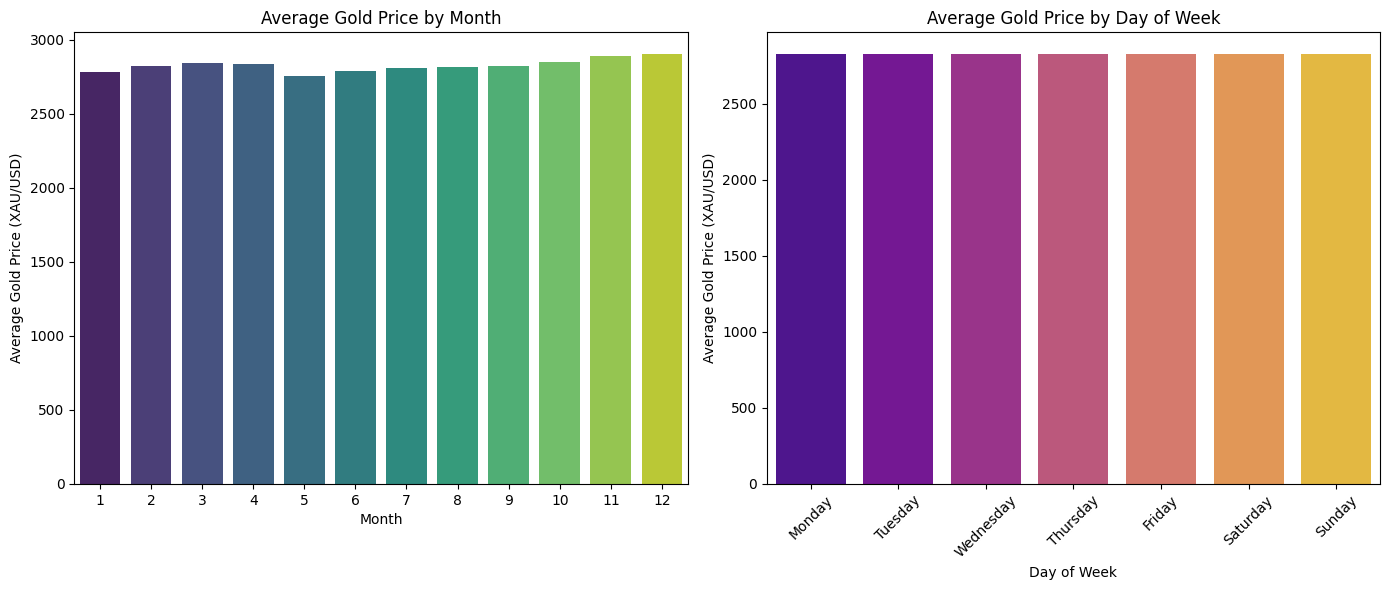

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot average gold price by month
plt.subplot(1, 2, 1)
sns.barplot(x='Month', y='Gold_Price_XAU_USD', data=monthly_avg_gold, palette='viridis')
plt.title('Average Gold Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Gold Price (XAU/USD)')

# Plot average gold price by day of week
plt.subplot(1, 2, 2)
sns.barplot(x='Day_of_Week_Name', y='Gold_Price_XAU_USD', data=dayofweek_avg_gold, palette='plasma')
plt.title('Average Gold Price by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Gold Price (XAU/USD)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()